In [15]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROJECT_ROOT = Path().resolve().parents[0]
DATA_DIR = PROJECT_ROOT / "data"


In [2]:
data_path = DATA_DIR / "Shot Chart Details Raw" /"raw_shotchart_S1_to_S4_main.csv"
shotdata_df = pd.read_csv(data_path)


In [3]:
print(shotdata_df.head(1))
shotdata_df.columns

    GAME_ID  GAME_EVENT_ID  PLAYER_ID   PLAYER_NAME     TEAM_ID  \
0  20500001             38     101106  Andrew Bogut  1610612749   

         TEAM_NAME  PERIOD  MINUTES_REMAINING  SECONDS_REMAINING EVENT_TYPE  \
0  Milwaukee Bucks       1                  5                 56  Made Shot   

   ...  HTM  VTM  source_pool draft_year season_num  season_string  is_hof  \
0  ...  PHI  MIL  cohort_main       2005          1        2005-06   False   

   shotstyle_eligible_hof  pull_status              pull_timestamp  
0                   False      Success  2026-03-30T01:18:55.457033  

[1 rows x 31 columns]


Index(['GAME_ID', 'GAME_EVENT_ID', 'PLAYER_ID', 'PLAYER_NAME', 'TEAM_ID',
       'TEAM_NAME', 'PERIOD', 'MINUTES_REMAINING', 'SECONDS_REMAINING',
       'EVENT_TYPE', 'ACTION_TYPE', 'SHOT_TYPE', 'SHOT_ZONE_BASIC',
       'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE', 'SHOT_DISTANCE', 'LOC_X', 'LOC_Y',
       'SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG', 'GAME_DATE', 'HTM', 'VTM',
       'source_pool', 'draft_year', 'season_num', 'season_string', 'is_hof',
       'shotstyle_eligible_hof', 'pull_status', 'pull_timestamp'],
      dtype='object')

In [4]:
data_path = DATA_DIR / "career_totals_targets_with_performance_analysis.csv"
career_total_df = pd.read_csv(data_path)


In [5]:
print(career_total_df.head(1))
career_total_df.columns

   PLAYER_ID SEASON_ID  LEAGUE_ID     TEAM_ID TEAM_ABBREVIATION  PLAYER_AGE  \
0    1629627   2019-20          0  1610612740               NOP        19.0   

   GP  GS  MIN  FGM  ...  AST  STL  BLK  TOV  PF  PTS      PLAYER_NAME  \
0  24  24  668  210  ...   50   16    9   59  42  540  Zion Williamson   

     TS_PCT       VPS  GmSc_Per48  
0  0.615988  1.484099   28.634731  

[1 rows x 31 columns]


Index(['PLAYER_ID', 'SEASON_ID', 'LEAGUE_ID', 'TEAM_ID', 'TEAM_ABBREVIATION',
       'PLAYER_AGE', 'GP', 'GS', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A',
       'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL',
       'BLK', 'TOV', 'PF', 'PTS', 'PLAYER_NAME', 'TS_PCT', 'VPS',
       'GmSc_Per48'],
      dtype='object')

In [6]:
data_path = DATA_DIR / "raw_game_logs_S1_to_S4.csv"
raw_games_df = pd.read_csv(data_path)


In [7]:
print(raw_games_df.head(1))
raw_games_df.columns

   SEASON_ID  Player_ID   Game_ID     GAME_DATE      MATCHUP WL  MIN  FGM  \
0      22019    1629627  21901287  Aug 09, 2020  NOP vs. SAS  L   27   10   

   FGA  FG_PCT  ...  AST  STL  BLK  TOV  PF  PTS  PLUS_MINUS  VIDEO_AVAILABLE  \
0   20     0.5  ...    1    0    0    1   3   25         -21                1   

       PLAYER_NAME  SEASON_STRING  
0  Zion Williamson        2019-20  

[1 rows x 29 columns]


Index(['SEASON_ID', 'Player_ID', 'Game_ID', 'GAME_DATE', 'MATCHUP', 'WL',
       'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA',
       'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF',
       'PTS', 'PLUS_MINUS', 'VIDEO_AVAILABLE', 'PLAYER_NAME', 'SEASON_STRING'],
      dtype='object')

In [8]:
class ShotEncoder(nn.Module):
    """
    Phase 1: Compresses a sequence of shots into a single game-level 'shot profile' vector.
    """
    def __init__(self, shot_feature_dim, hidden_dim):
        super(ShotEncoder, self).__init__()
        # Using GRU for sequence modeling; can be swapped for TransformerEncoder
        self.gru = nn.GRU(
            input_size=shot_feature_dim, 
            hidden_size=hidden_dim, 
            batch_first=True
        )

    def forward(self, shots_seq):
        # shots_seq shape: [batch_size * max_games, max_shots, shot_feature_dim]
        # output shape: [batch_size * max_games, max_shots, hidden_dim]
        # hidden shape: [1, batch_size * max_games, hidden_dim]
        _, hidden = self.gru(shots_seq)
        
        # We only want the final hidden state (the summary of all shots in that game)
        # shape: [batch_size * max_games, hidden_dim]
        return hidden.squeeze(0) 


class GameEncoder(nn.Module):
    """
    Phase 2: Fuses raw game stats with the shot profile, then compresses 
    a season of games into a single 'season profile' vector.
    """
    def __init__(self, game_stat_dim, shot_hidden_dim, hidden_dim):
        super(GameEncoder, self).__init__()
        # We concatenate the raw game stats with the output of the ShotEncoder
        fused_dim = game_stat_dim + shot_hidden_dim
        
        self.gru = nn.GRU(
            input_size=fused_dim, 
            hidden_size=hidden_dim, 
            batch_first=True
        )

    def forward(self, game_stats_seq, shot_profiles, batch_size, max_games):
        # game_stats_seq shape: [batch_size, max_games, game_stat_dim]
        # shot_profiles shape:  [batch_size * max_games, shot_hidden_dim]
        
        # Reshape shot profiles to match game sequence dimensions
        shot_profiles = shot_profiles.view(batch_size, max_games, -1)
        
        # Concatenate raw game stats with the embedded shot data
        # shape: [batch_size, max_games, game_stat_dim + shot_hidden_dim]
        fused_game_data = torch.cat((game_stats_seq, shot_profiles), dim=2)
        
        _, hidden = self.gru(fused_game_data)
        
        # Final hidden state represents the entire season
        # shape: [batch_size, hidden_dim]
        return hidden.squeeze(0)


class HCFN(nn.Module):
    """
    Phase 3 (The Master Module): Processes the seasons and forecasts the next year's VPS.
    """
    def __init__(self, shot_dim, game_dim, season_dim, shot_hidden, game_hidden, rnn_hidden):
        super(HCFN, self).__init__()
        
        self.shot_encoder = ShotEncoder(shot_feature_dim=shot_dim, hidden_dim=shot_hidden)
        self.game_encoder = GameEncoder(game_stat_dim=game_dim, shot_hidden_dim=shot_hidden, hidden_dim=game_hidden)
        
        # RNN to track career trajectory over multiple seasons
        fused_season_dim = season_dim + game_hidden
        self.career_rnn = nn.GRU(
            input_size=fused_season_dim, 
            hidden_size=rnn_hidden, 
            batch_first=True
        )
        
        # Final prediction head mapping to a single continuous variable (VPS)
        self.regressor = nn.Sequential(
            nn.Dropout(p=0.2),
            nn.Linear(rnn_hidden, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 1) # Outputting a single float (VPS)
        )

    def forward(self, shots, games, seasons):
        """
        shots:   [batch, max_seasons, max_games, max_shots, shot_dim]
        games:   [batch, max_seasons, max_games, game_dim]
        seasons: [batch, max_seasons, season_dim]
        """
        B, S, G, Sh, F_shot = shots.shape
        _, _, _, F_game = games.shape
        _, _, F_season = seasons.shape

        # We will collect the embedded seasons here
        season_embeddings = []

        # Iterate through each season historically
        for s in range(S):
            # 1. Process all shots for all games in this specific season
            # Flatten batch and games to process efficiently in parallel
            season_shots = shots[:, s, :, :, :].reshape(B * G, Sh, F_shot)
            shot_profiles = self.shot_encoder(season_shots) 
            
            # 2. Process all games in this specific season
            season_games = games[:, s, :, :] # shape: [B, G, F_game]
            season_profile = self.game_encoder(season_games, shot_profiles, B, G)
            
            # 3. Concatenate the resulting game/shot profile with the top-level season stats
            top_level_season_stats = seasons[:, s, :] # shape: [B, F_season]
            fused_season = torch.cat((top_level_season_stats, season_profile), dim=1)
            
            season_embeddings.append(fused_season)

        # 4. Stack seasons back into a sequence: [batch_size, max_seasons, fused_season_dim]
        career_sequence = torch.stack(season_embeddings, dim=1)
        
        # 5. Process the career trajectory
        career_out, _ = self.career_rnn(career_sequence)
        
        # We take the output of the LAST season step to predict the NEXT season's VPS
        # shape: [batch_size, rnn_hidden]
        final_career_state = career_out[:, -1, :] 
        
        # 6. Predict Target (VPS)
        predicted_vps = self.regressor(final_career_state)
        
        return predicted_vps


### The HCFN Data Flow Diagram

* **Phase 1: Shot Processing (The Micro Level)**
    * **Input:** `shots` tensor — reshaped to `[B*G, Sh, F_shot]` (All shots taken by a player across all games in a specific season).
    * **Module:** `self.shot_encoder`
    * **Output:** `shot_profiles` — The network compresses the sequence of shots for a single game into one dense mathematical vector. 

* **Phase 2: Game Processing (The Meso Level)**
    * **Inputs:** * `season_games` tensor `[B, G, F_game]` (The raw box score stats for those games).
        * `shot_profiles` (The embedded shot context from Phase 1).
    * **Module:** `self.game_encoder`
    * **Output:** `season_profile` — The network fuses the box scores with the shot mechanics and compresses the sequence of all games played that year into a single vector representing the entire season.

* **Phase 3: Season Fusion (The Context Level)**
    * **Inputs:**
        * `top_level_season_stats` tensor `[B, F_season]` (General context like Player Age, Total Minutes).
        * `season_profile` (The granular game/shot summary from Phase 2).
    * **Action:** Concatenation (`torch.cat` on `dim=1`).
    * **Output:** `fused_season` — A complete mathematical snapshot of one year in a player's career, containing everything from their age down to their shot coordinates.
    * *Note: Phases 1 through 3 loop sequentially for every season (S) in the player's history.*

* **Phase 4: Career Trajectory (The Macro Level)**
    * **Input:** `career_sequence` `[B, S, fused_season_dim]` (A chronological stack of all the `fused_season` vectors generated in the loop).
    * **Module:** `self.career_rnn` (A GRU layer designed to remember year-over-year development, aging, and momentum).
    * **Output:** `final_career_state` — The network isolates the final hidden state of the RNN (`career_out[:, -1, :]`). This represents the player's total cumulative development up to the present moment.

* **Phase 5: The Forecast (The Output Level)**
    * **Input:** `final_career_state`
    * **Module:** `self.regressor` (A Multi-Layer Perceptron: Linear -> ReLU -> Linear).
    * **Output:** `predicted_vps` — A single scalar value forecasting the player's target metric for the upcoming season.

In [9]:
def pad_and_extract(df, group_keys, feature_cols, max_length):
    """A helper function to group data and pad to a maximum length."""
    grouped = df.groupby(group_keys)
    padded_data = []
    
    for name, group in grouped:
        # Extract the raw numbers
        values = group[feature_cols].values
        
        # Truncate if too long, pad with zeros if too short
        if len(values) > max_length:
            values = values[:max_length]
        else:
            padding = np.zeros((max_length - len(values), len(feature_cols)))
            values = np.vstack((values, padding))
            
        padded_data.append(values)
        
    return np.array(padded_data)

In [10]:
def analyze_nba_dimensions(career_df, game_df, shot_df):
    print("--- NBA Dataset Dimension Analyzer ---\n")
    
    total_players = career_df['PLAYER_ID'].nunique()
    print(f"Total Unique Players: {total_players}")

    max_seasons = career_df.groupby('PLAYER_ID')['SEASON_ID'].nunique().max()
    print(f"Max Seasons per player (MAX_SEASONS): {max_seasons}")

    max_games = game_df.groupby(['Player_ID', 'SEASON_STRING'])['Game_ID'].nunique().max()
    print(f"Max Games per season (MAX_GAMES): {max_games}")

    max_shots = shot_df.groupby(['PLAYER_ID', 'GAME_ID']).size().max()
    print(f"Max Shots per game (MAX_SHOTS): {max_shots}")

# Run the function
analyze_nba_dimensions(career_total_df, raw_games_df, shotdata_df)

MAX_SEASONS = 4
MAX_GAMES = 84
MAX_SHOTS = 40

--- NBA Dataset Dimension Analyzer ---

Total Unique Players: 1049
Max Seasons per player (MAX_SEASONS): 23
Max Games per season (MAX_GAMES): 84
Max Shots per game (MAX_SHOTS): 40


In [11]:
shotdata_df['SHOT_MADE_NUMERIC'] = (shotdata_df['SHOT_MADE_FLAG'] == 'Made Shot').astype(float)
shot_features = ['LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'SHOT_MADE_NUMERIC']
game_features = [
    'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 
    'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 
    'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS'
]
season_features = ['PLAYER_AGE', 'GP', 'MIN', 'PTS']
print("--- Data Poisoning Diagnostic Check ---\n")

# 1. Check the Target Variable (Crucial)
target_nans = career_total_df['VPS'].isna().sum()
print(f"Target (VPS) NaNs: {target_nans}")

# 2. Check Season Features
print("\n--- Season Features (career_total_df) ---")
for col in season_features:
    nans = career_total_df[col].isna().sum()
    infs = np.isinf(career_total_df[col]).sum()
    if nans > 0 or infs > 0:
        print(f"  {col}: {nans} NaNs | {infs} Infs")
        
# 3. Check Game Features
print("\n--- Game Features (raw_games_df) ---")
for col in game_features:
    nans = raw_games_df[col].isna().sum()
    infs = np.isinf(raw_games_df[col]).sum()
    if nans > 0 or infs > 0:
        print(f"  {col}: {nans} NaNs | {infs} Infs")

# 4. Check Shot Features
print("\n--- Shot Features (shotdata_df) ---")
for col in shot_features:
    nans = shotdata_df[col].isna().sum()
    infs = np.isinf(shotdata_df[col]).sum()
    if nans > 0 or infs > 0:
        print(f"  {col}: {nans} NaNs | {infs} Infs")

print("\nDiagnostic Complete.")

--- Data Poisoning Diagnostic Check ---

Target (VPS) NaNs: 0

--- Season Features (career_total_df) ---

--- Game Features (raw_games_df) ---

--- Shot Features (shotdata_df) ---
  LOC_X: 137 NaNs | 0 Infs
  LOC_Y: 137 NaNs | 0 Infs
  SHOT_DISTANCE: 137 NaNs | 0 Infs

Diagnostic Complete.


In [12]:
# Because NaN in Shot Feature drop them makes more sense
shotdata_df = shotdata_df.dropna(subset=['LOC_X', 'LOC_Y', 'SHOT_DISTANCE'])

In [13]:
shotdata_df['SHOT_MADE_NUMERIC'] = (shotdata_df['SHOT_MADE_FLAG'] == 'Made Shot').astype(float)
shot_features = ['LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'SHOT_MADE_NUMERIC']
game_features = [
    'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 
    'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 
    'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS'
]
season_features = ['PLAYER_AGE', 'GP', 'MIN', 'PTS']

def build_fast_player_cache(career_df, game_df, shot_df):
    player_cache = {}
    players = career_df['PLAYER_ID'].unique()
    
    print("Grouping DataFrames for O(1) lookups (This takes a few seconds)...")
    career_grouped = dict(tuple(career_df.groupby('PLAYER_ID')))
    game_grouped = dict(tuple(game_df.groupby(['Player_ID', 'SEASON_STRING'])))
    shot_grouped = dict(tuple(shot_df.groupby(['PLAYER_ID', 'GAME_ID'])))
    
    print("Building tensors into RAM...")
    for player_id in tqdm(players, desc="Pre-processing Players"):
        p_seasons = career_grouped.get(player_id)
        
        # Require at least 5 seasons to make ANY prediction
        if p_seasons is None or len(p_seasons) < 5:
            continue 
            
        # Extract EXACTLY the first 4 seasons as Input
        historical_seasons = p_seasons.iloc[0:4] 
        season_ids = historical_seasons['SEASON_ID'].tolist()
        
        # Extract years 5, 6, and 7 (or however many they played up to year 7) as Target
        target_seasons = p_seasons.iloc[4:7] 
        target_vps = target_seasons['VPS'].mean()

        historical_seasons = p_seasons.iloc[:-1].tail(MAX_SEASONS)
        season_ids = historical_seasons['SEASON_ID'].tolist()
        
        season_tensor = np.zeros((MAX_SEASONS, len(season_features)))
        game_tensor = np.zeros((MAX_SEASONS, MAX_GAMES, len(game_features)))
        shot_tensor = np.zeros((MAX_SEASONS, MAX_GAMES, MAX_SHOTS, len(shot_features)))
        
        hist_vals = historical_seasons[season_features].values
        if len(hist_vals) > 0:
            season_tensor[-len(hist_vals):] = hist_vals 
            
        start_idx = MAX_SEASONS - len(season_ids)
        
        for s_offset, s_id in enumerate(season_ids):
            s_idx = start_idx + s_offset 
            s_games = game_grouped.get((player_id, s_id))
            
            if s_games is not None:
                s_games = s_games.head(MAX_GAMES)
                game_tensor[s_idx, :len(s_games), :] = s_games[game_features].values
                
                for g_idx, g_id in enumerate(s_games['Game_ID']):
                    g_shots = shot_grouped.get((player_id, g_id))
                    
                    if g_shots is not None:
                        g_shots = g_shots.head(MAX_SHOTS)
                        shot_tensor[s_idx, g_idx, :len(g_shots), :] = g_shots[shot_features].values
        
        # Save to dictionary as PyTorch tensors
        player_cache[player_id] = {
            'shots': torch.FloatTensor(shot_tensor),
            'games': torch.FloatTensor(game_tensor),
            'seasons': torch.FloatTensor(season_tensor),
            'target': torch.FloatTensor([target_vps])
        }
        
    return player_cache

# --- Execute Pre-processing ---
player_data_cache = build_fast_player_cache(career_total_df, raw_games_df, shotdata_df)

class NBAPlayerDataset(Dataset):
    def __init__(self, data_cache):
        self.data_cache = data_cache
        self.players = list(data_cache.keys())

    def __len__(self):
        return len(self.players)

    def __getitem__(self, idx):
        player_id = self.players[idx]
        data = self.data_cache[player_id]
        
        # Instantly return the pre-computed tensors
        return data['shots'], data['games'], data['seasons'], data['target']


Grouping DataFrames for O(1) lookups (This takes a few seconds)...
Building tensors into RAM...


Pre-processing Players: 100%|██████████| 1049/1049 [00:05<00:00, 188.19it/s]


In [ ]:
# shotdata_df['SHOT_MADE_NUMERIC'] = (shotdata_df['SHOT_MADE_FLAG'] == 'Made Shot').astype(float)
# shot_features = ['LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'SHOT_MADE_NUMERIC']
# game_features = [
#     'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 
#     'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 
#     'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS'
# ]
# season_features = ['PLAYER_AGE', 'GP', 'MIN', 'PTS']

# # SLOW VERSION
# class NBAPlayerDataset(Dataset):
#     def __init__(self, career_df, game_df, shot_df):
#         # We need a list of unique players to iterate through
#         self.players = career_df['PLAYER_ID'].unique()
#         self.career_df = career_df
#         self.game_df = game_df
#         self.shot_df = shot_df

#     def __len__(self):
#         return len(self.players)

#     def __getitem__(self, idx):
#         player_id = self.players[idx]
#         # --- 1. Get Target (VPS) ---
#         p_seasons = self.career_df[self.career_df['PLAYER_ID'] == player_id]
#         # Target is the VPS of their LAST available season
#         target_vps = p_seasons.iloc[-1]['VPS']

#         # --- 2. Get Historical Context (All seasons EXCEPT the last one) ---
#         historical_seasons = p_seasons.iloc[:-1].tail(MAX_SEASONS)
#         season_ids = historical_seasons['SEASON_ID'].tolist()

#         # --- 3. Initialize Empty Tensors (Filled with 0.0 for padding) ---
#         season_tensor = np.zeros((MAX_SEASONS, len(season_features)))
#         game_tensor = np.zeros((MAX_SEASONS, MAX_GAMES, len(game_features)))
#         shot_tensor = np.zeros((MAX_SEASONS, MAX_GAMES, MAX_SHOTS, len(shot_features)))

#         # --- 4. Fill the Tensors ---
#         # Fill seasons (padding from the front so the most recent season is at the end)
#         hist_vals = historical_seasons[['PLAYER_AGE', 'GP', 'MIN', 'PTS']].values
#         if len(hist_vals) > 0:
#             season_tensor[-len(hist_vals):] = hist_vals
       
#         # Calculate the starting index for seasons so we align games/shots correctly
#         start_idx = MAX_SEASONS - len(season_ids)

#         for s_offset, s_id in enumerate(season_ids):
#             s_idx = start_idx + s_offset
           
#             # Get games for this season
#             s_games = self.game_df[(self.game_df['Player_ID'] == player_id) &
#                                    (self.game_df['SEASON_STRING'] == s_id)].head(MAX_GAMES)

#             if len(s_games) > 0:
#                 game_features_cols = ['MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT',
#                                       'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST',
#                                       'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS']
#                 game_tensor[s_idx, :len(s_games), :] = s_games[game_features_cols].values

#                 # Get shots for these games
#                 for g_idx, g_id in enumerate(s_games['Game_ID']):
#                     g_shots = self.shot_df[(self.shot_df['PLAYER_ID'] == player_id) &
#                                            (self.shot_df['GAME_ID'] == g_id)].head(MAX_SHOTS)

#                     if len(g_shots) > 0:
#                         shot_features_cols = ['LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'SHOT_MADE_NUMERIC']
#                         shot_tensor[s_idx, g_idx, :len(g_shots), :] = g_shots[shot_features_cols].values

#         # Convert all to PyTorch Tensors
#         return (torch.FloatTensor(shot_tensor),
#                 torch.FloatTensor(game_tensor),
#                 torch.FloatTensor(season_tensor),
#                 torch.FloatTensor([target_vps]))

# full_dataset = NBAPlayerDataset(career_total_df, raw_games_df, shotdata_df)

In [23]:
full_dataset = NBAPlayerDataset(player_data_cache)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

model = HCFN(
    shot_dim=len(shot_features), 
    game_dim=len(game_features), 
    season_dim=len(season_features),
    shot_hidden=32, game_hidden=64, rnn_hidden=64
)

model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
criterion = torch.nn.MSELoss()

epochs = 100
epoch_loop = tqdm(range(epochs), desc="Training Progress")

history_train_loss = []
history_train_mae = []
history_val_mae = []

for epoch in epoch_loop:
    
    # ==========================
    # TRAINING BLOCK
    # ==========================
    model.train()
    total_train_loss = 0
    total_train_mae = 0
    
    for shots, games, seasons, target in train_loader:
        shots, games, seasons, target = shots.to(device), games.to(device), seasons.to(device), target.to(device)
        
        optimizer.zero_grad()
        predictions = model(shots, games, seasons)
        loss = criterion(predictions, target)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

        with torch.no_grad():
            abs_err = torch.abs(predictions - target).sum()
            total_train_mae += abs_err.item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_mae = total_train_mae / len(train_dataset)

    # ==========================
    # VALIDATION BLOCK (Evaluation)
    # ==========================
    model.eval()
    total_val_error = 0
    
    with torch.no_grad():
        for shots, games, seasons, target in val_loader:
            shots, games, seasons, target = shots.to(device), games.to(device), seasons.to(device), target.to(device)
            
            predictions = model(shots, games, seasons)
            
            # Calculate Absolute Error (Actual difference in VPS)
            absolute_error = torch.abs(predictions - target).sum()
            total_val_error += absolute_error.item()
            
    # Calculate Mean Absolute Error across all validation players
    # Using len(val_dataset) gives us the exact average error per player
    val_mae = total_val_error / len(val_dataset)
    
    history_train_loss.append(avg_train_loss)
    history_train_mae.append(avg_train_mae)
    history_val_mae.append(val_mae)
    
    # Update progress bar
    epoch_loop.set_postfix(Train_MSE=f"{avg_train_loss:.4f}", Train_MAE=f"{avg_train_mae:.4f}", Val_MAE=f"{val_mae:.4f}")

Training Progress: 100%|██████████| 100/100 [00:55<00:00,  1.80it/s, Train_MAE=0.2451, Train_MSE=0.1279, Val_MAE=0.2121]


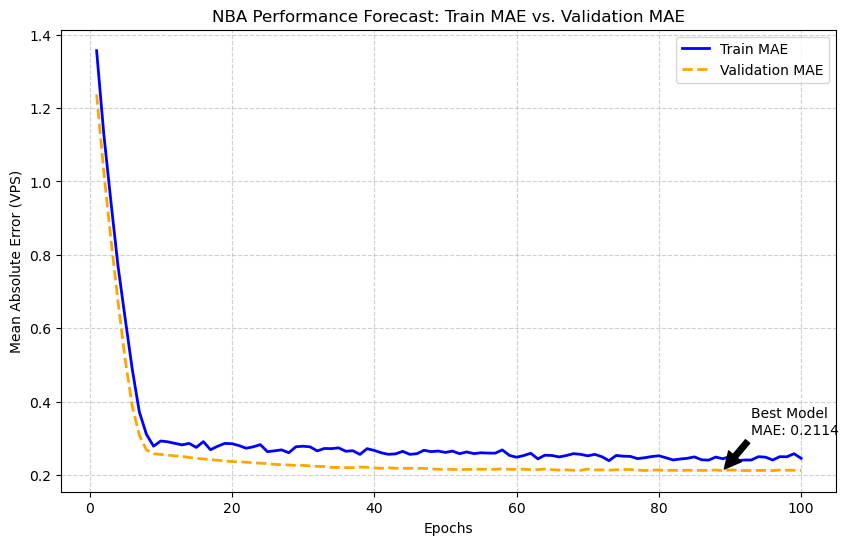

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), history_train_mae, label='Train MAE', color='blue', linewidth=2)
plt.plot(range(1, epochs + 1), history_val_mae, label='Validation MAE', color='orange', linewidth=2, linestyle='--')

plt.title('NBA Performance Forecast: Train MAE vs. Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (VPS)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Find the best epoch (lowest validation error)
best_epoch = np.argmin(history_val_mae)
plt.annotate(f'Best Model\nMAE: {history_val_mae[best_epoch]:.4f}', 
             xy=(best_epoch + 1, history_val_mae[best_epoch]), 
             xytext=(best_epoch + 5, history_val_mae[best_epoch] + 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

In [ ]:
cluster_modeling_predictors_k5
shot_embedding_player